In [1]:
import numpy as np 
import tensorflow as tf
import cv2 as cv
import os
import mediapipe as mp 


### Analysis After Cleaning 

In [2]:
from dataLoader import quick_load
# Path to your dataset
dataset_path = r"D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
cleaned_data, cleaned_labels = quick_load(dataset_path)
print(f"Loaded {len(cleaned_data)} samples")


METHOD 1: One-line loading
📦 Loading metadata from cache: D:\GP\cleaned_landmarks_100words\cleaned_landmarks_100words\.cache\metadata.pkl
✅ Loaded metadata for 2984 files


Loading data: 100%|██████████| 2984/2984 [00:02<00:00, 1483.72it/s]

Loaded 2984 samples


In [3]:
cleaned_data[100].shape


(60, 438)

In [4]:

print(f"the number of unique labels is: {len(np.unique(cleaned_labels))}")
print(f"the first 100 unique labels are: {np.unique(cleaned_labels)[:]}")

the number of unique labels is: 105
the first 100 unique labels are: ['1 DOLLAR' '5 DOLLARS' '8 HOUR' '9 OCLOCK' 'A LITTLE BIT' 'A-LINE BOB'
 'ABBREVIATE' 'ABOUT' 'ABOVE' 'ABSOLUTELY NOTHING' 'ACCENT' 'ACCEPT'
 'ACCESS' 'ACCIDENT' 'ACCOMPLISH' 'ACCORDION' 'ACCOUNTANT' 'ACQUIRE' 'ACT'
 'ACTION' 'ACTOR' 'ADD' 'ADDICT' 'ADDRESS' 'ADMIRE' 'ADMIT' 'ADOPT'
 'ADULT' 'ADVANTAGE' 'ADVERTISE' 'AFRICA' 'AFTER' 'AFTERNOON' 'AGAIN'
 'AGAINST' 'AGE' 'AGENCY' 'AGREEMENT' 'AIRPLANE' 'ALARM' 'ALASKA'
 'ALCOHOL' 'ALIGN' 'ALL' 'ALL DAY' 'ALL GONE' 'ALL OF_SUDDEN' 'ALL OVER'
 'ALL OVER_BODY' 'ALL TOGETHER' 'ALL WAY' 'ALONE' 'ALPHABET' 'ALRIGHT'
 'ALWAYS' 'AMAZING' 'AMERICA' 'ANALYZE' 'AND' 'ANGEL' 'ANGRY' 'ANIMAL'
 'ANNOUNCE' 'ANSWER' 'ANTLERS' 'ANY' 'ANYONE' 'APART' 'APPEAR' 'APPLE'
 'APPOINTMENT' 'APRIL' 'ARCHEOLOGY' 'AREA' 'ARGUE' 'ARIZONA' 'ARM' 'ARMY'
 'ARREST1' 'ARREST2' 'ARREST3' 'ARRIVE' 'ART' 'ARTICLE' 'ARTICULATE SIGN'
 'ASIA' 'ASK' 'ASSEMBLY' 'ASSIGN' 'ASSIST' 'ASSISTANT' 'ASTRONAUT' 'AT'
 'ATH

✅ Quick Analysis Results:
  • 2984 total videos
  • 105 unique glosses
  • Average length: 79.4 frames
  • Most common: ARM (61 videos)
  • Rarest: AUTISM (2 videos)
📊 SIGN LANGUAGE DATA ANALYSIS REPORT

📈 Basic Statistics:
  Total videos: 2984
  Unique glosses: 105
  Average videos/gloss: 28.42

📏 Frame Length Statistics:
  Min: 21
  Max: 268
  Mean: 79.42
  Median: 74.00
  Std: 30.99

🔍 Quality Issues:
  Has nan: 0 (0.00%)
  Has inf: 0 (0.00%)
  All zero: 0 (0.00%)
  Corrupted: 0 (0.00%)

🔤 Alphabet Distribution (Top 10):
letter  total_videos  unique_labels
     A          2873            101
     D            56              2
     H            29              1
     O            26              1


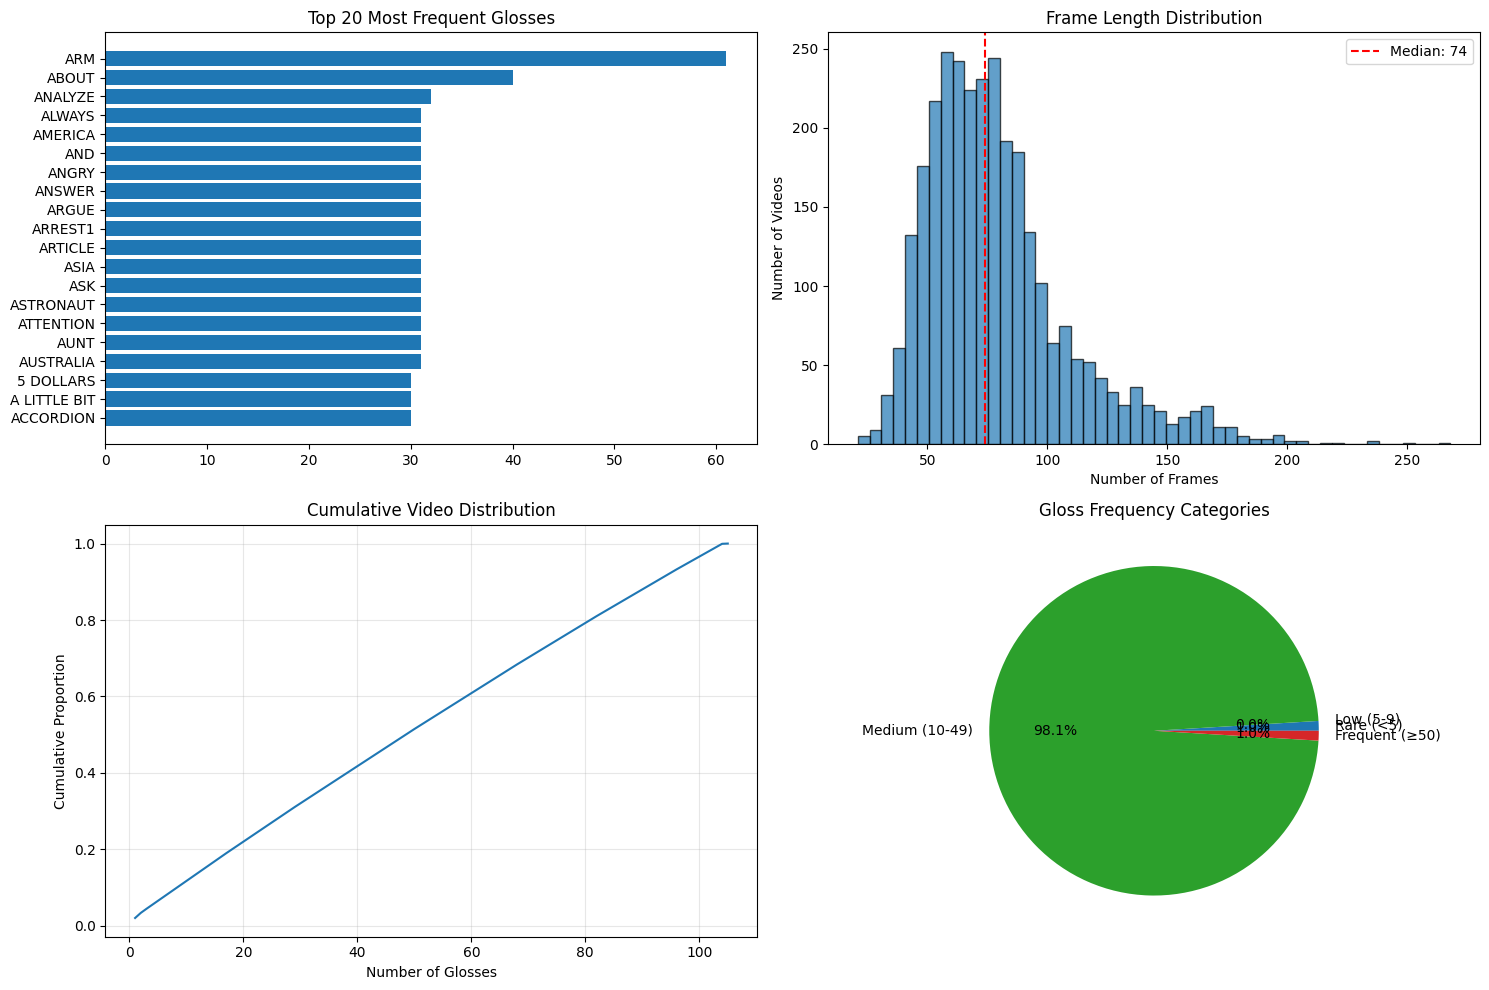

      label  count
76      ARM     61
7     ABOUT     40
57  ANALYZE     32
78  ARREST1     31
63   ANSWER     31
{'min': 21, 'max': 268, 'mean': 79.42493297587131, 'median': 74.0, 'std': 30.99385471059134, 'percentiles': {10: 48.0, 25: 58.0, 50: 74.0, 75: 92.0, 90: 120.0, 95: 144.0, 99: 178.0}}
{'has_nan': 0, 'has_inf': 0, 'all_zero': 0, 'corrupted': 0}
Custom Analysis:
  Total: 2984 videos
  Unique: 105 signs
  Avg frames: 79.4
  Max frames: 268
  Min frames: 21


Counter({'ARM': 61,
         'ABOUT': 40,
         'ANALYZE': 32,
         'ALWAYS': 31,
         'AMERICA': 31,
         'AND': 31,
         'ANGRY': 31,
         'ANSWER': 31,
         'ARGUE': 31,
         'ARREST1': 31,
         'ARTICLE': 31,
         'ASIA': 31,
         'ASK': 31,
         'ASTRONAUT': 31,
         'ATTENTION': 31,
         'AUNT': 31,
         'AUSTRALIA': 31,
         '5 DOLLARS': 30,
         'A LITTLE BIT': 30,
         'ACCORDION': 30,
         'ALPHABET': 30,
         'ANGEL': 30,
         'ANIMAL': 30,
         'ANNOUNCE': 30,
         'APART': 30,
         'APPLE': 30,
         'ARREST2': 30,
         'ASSIST': 30,
         'AT': 30,
         '8 HOUR': 29,
         'ABSOLUTELY NOTHING': 29,
         'ACCESS': 29,
         'ACTION': 29,
         'ADDRESS': 29,
         'ADMIRE': 29,
         'ADULT': 29,
         'AGAINST': 29,
         'AIRPLANE': 29,
         'ALIGN': 29,
         'ALL': 29,
         'ANTLERS': 29,
         'ANY': 29,
         'APRIL': 

In [8]:
# Method 1: Simple one-line analysis
from analysis import quick_analyze
from collections import Counter
import pandas as pd
# Quick analysis without saving
quick_analyze(cleaned_data, cleaned_labels)

# Method 2: Full analysis with custom settings
from analysis import SignLanguageAnalyzer

# Create analyzer with custom settings
analyzer = SignLanguageAnalyzer(
    output_dir="D:\\GP\\MyAnalysis",
    min_frames=15,
    max_frames=400
)

# Run full analysis
results = analyzer.generate_report(cleaned_data, cleaned_labels)

# Access results
print(results['label_distribution'].head())
print(results['frame_stats'])
print(results['quality_issues'])

# Method 3: Individual analyses
label_counter, label_df = analyzer.analyze_label_distribution(cleaned_labels)
frame_lengths, frame_stats = analyzer.analyze_frame_lengths(cleaned_data, cleaned_labels)
quality_issues = analyzer.analyze_data_quality(cleaned_data, cleaned_labels)

# Method 4: Custom analysis pipeline
def my_custom_analysis(data, labels):
    analyzer = SignLanguageAnalyzer(output_dir="D:\\GP\\CustomAnalysis")
    
    # Run only what you need
    label_counter = Counter(labels)
    frame_lengths = [len(seq) for seq in data]
    
    print(f"Custom Analysis:")
    print(f"  Total: {len(data)} videos")
    print(f"  Unique: {len(label_counter)} signs")
    print(f"  Avg frames: {np.mean(frame_lengths):.1f}")
    print(f"  Max frames: {max(frame_lengths)}")
    print(f"  Min frames: {min(frame_lengths)}")
    
    # Save custom results
    pd.DataFrame({
        'label': list(label_counter.keys()),
        'count': list(label_counter.values())
    }).to_csv(analyzer.output_dir / 'custom_labels.csv', index=False)
    
    return label_counter

# Run custom analysis
my_custom_analysis(cleaned_data, cleaned_labels)

### Analysis Before Cleaning 

In [9]:
from dataLoader import quick_load
# Path to your dataset
dataset_path = r"D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words"
    
# ============================================================
# METHOD 1: One-line loading (simplest)
# ============================================================
print("\n" + "="*60)
print("METHOD 1: One-line loading")
print("="*60)
ordinary_data, ordinary_labels = quick_load(dataset_path)
print(f"Loaded {len(ordinary_data)} samples")


METHOD 1: One-line loading
🔍 Scanning directory: D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words
📁 Found 3283 .npy files


Loading metadata: 100%|██████████| 3283/3283 [00:00<00:00, 329786.37it/s]


✅ Metadata cached to D:\GP\before_cleaning_landmarks_100words\before_cleaning_landmarks_100words\.cache\metadata.pkl


Loading data: 100%|██████████| 3283/3283 [00:03<00:00, 988.64it/s] 

Loaded 3283 samples


✅ Quick Analysis Results:
  • 3283 total videos
  • 102 unique glosses
  • Average length: 81.4 frames
  • Most common: ARREST (92 videos)
  • Rarest: 7-SEEDSOUR (1 videos)
📊 SIGN LANGUAGE DATA ANALYSIS REPORT

📈 Basic Statistics:
  Total videos: 3283
  Unique glosses: 102
  Average videos/gloss: 32.19

📏 Frame Length Statistics:
  Min: 3
  Max: 494
  Mean: 81.37
  Median: 74.00
  Std: 35.97

🔍 Quality Issues:
  Has nan: 0 (0.00%)
  Has inf: 0 (0.00%)
  All zero: 0 (0.00%)
  Corrupted: 0 (0.00%)

🔤 Alphabet Distribution (Top 10):
letter  total_videos  unique_labels
     A          3157             97
     D            63              2
     H            31              1
     O            31              1


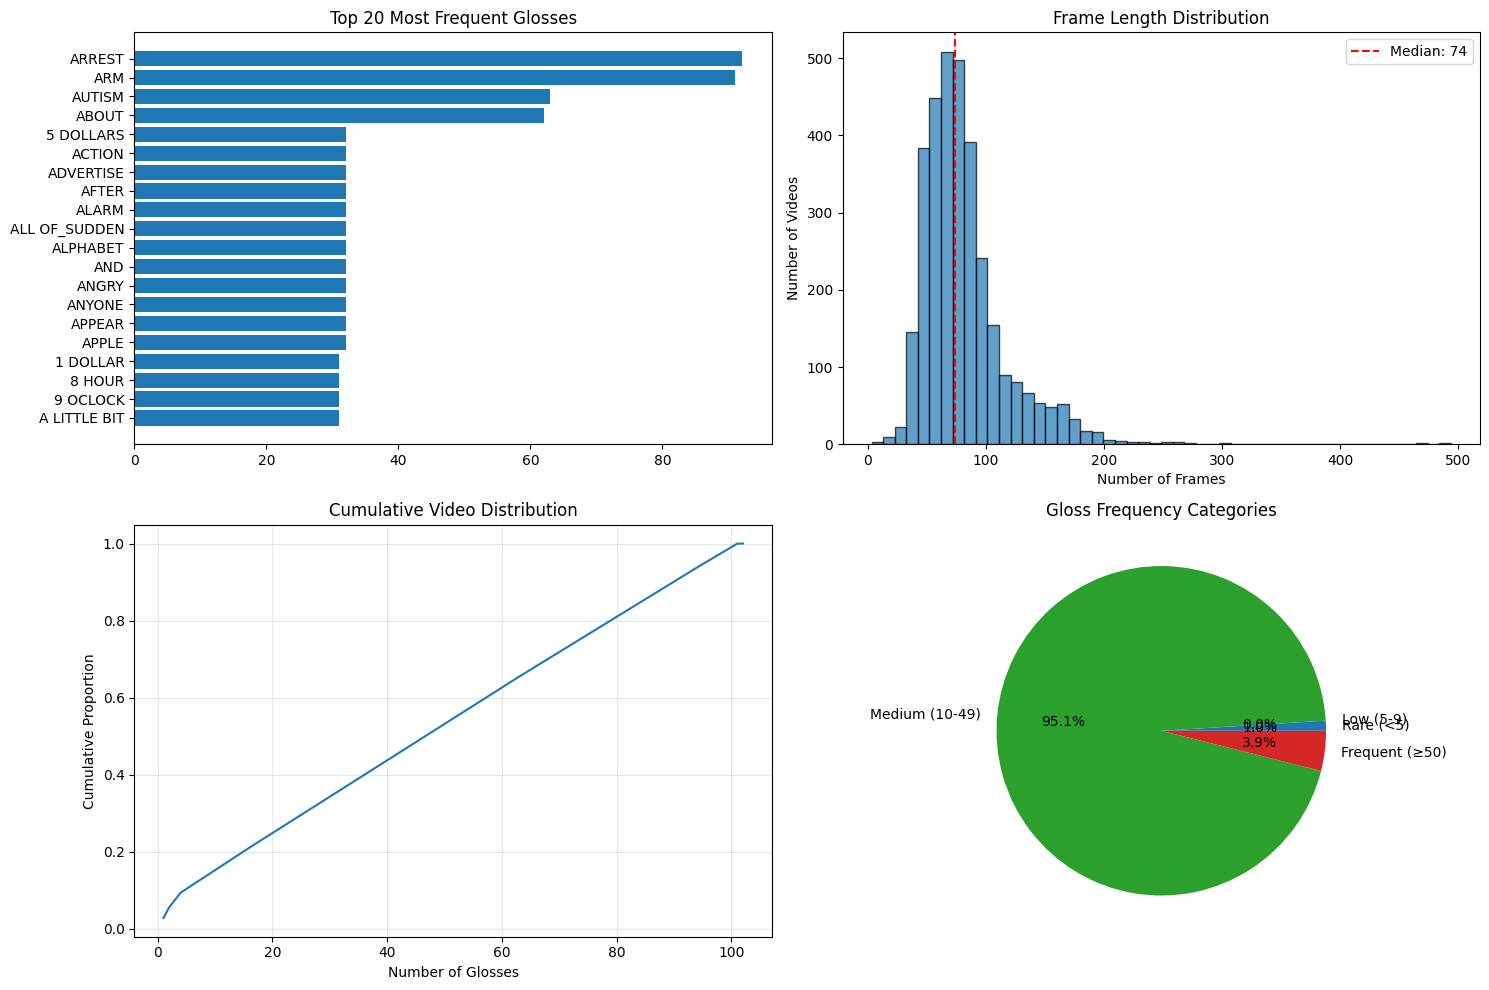

        label  count
79     ARREST     92
77        ARM     91
100    AUTISM     63
8       ABOUT     62
53   ALPHABET     32
{'min': 3, 'max': 494, 'mean': 81.37496192506853, 'median': 74.0, 'std': 35.96928759762007, 'percentiles': {10: 47.0, 25: 58.0, 50: 74.0, 75: 93.5, 90: 127.0, 95: 157.0, 99: 194.0}}
{'has_nan': 0, 'has_inf': 0, 'all_zero': 0, 'corrupted': 0}
Custom Analysis:
  Total: 2984 videos
  Unique: 105 signs
  Avg frames: 79.4
  Max frames: 268
  Min frames: 21


Counter({'ARM': 61,
         'ABOUT': 40,
         'ANALYZE': 32,
         'ALWAYS': 31,
         'AMERICA': 31,
         'AND': 31,
         'ANGRY': 31,
         'ANSWER': 31,
         'ARGUE': 31,
         'ARREST1': 31,
         'ARTICLE': 31,
         'ASIA': 31,
         'ASK': 31,
         'ASTRONAUT': 31,
         'ATTENTION': 31,
         'AUNT': 31,
         'AUSTRALIA': 31,
         '5 DOLLARS': 30,
         'A LITTLE BIT': 30,
         'ACCORDION': 30,
         'ALPHABET': 30,
         'ANGEL': 30,
         'ANIMAL': 30,
         'ANNOUNCE': 30,
         'APART': 30,
         'APPLE': 30,
         'ARREST2': 30,
         'ASSIST': 30,
         'AT': 30,
         '8 HOUR': 29,
         'ABSOLUTELY NOTHING': 29,
         'ACCESS': 29,
         'ACTION': 29,
         'ADDRESS': 29,
         'ADMIRE': 29,
         'ADULT': 29,
         'AGAINST': 29,
         'AIRPLANE': 29,
         'ALIGN': 29,
         'ALL': 29,
         'ANTLERS': 29,
         'ANY': 29,
         'APRIL': 

In [10]:
# Method 1: Simple one-line analysis
from analysis import quick_analyze
from collections import Counter
import pandas as pd
# Quick analysis without saving
quick_analyze(ordinary_data, ordinary_labels)

# Method 2: Full analysis with custom settings
from analysis import SignLanguageAnalyzer

# Create analyzer with custom settings
analyzer = SignLanguageAnalyzer(
    output_dir="D:\\GP\\MyAnalysisforOrdinary",
    min_frames=15,
    max_frames=400
)

# Run full analysis
results = analyzer.generate_report(ordinary_data, ordinary_labels)

# Access results
print(results['label_distribution'].head())
print(results['frame_stats'])
print(results['quality_issues'])

# Method 3: Individual analyses
label_counter, label_df = analyzer.analyze_label_distribution(ordinary_labels)
frame_lengths, frame_stats = analyzer.analyze_frame_lengths(ordinary_data, ordinary_labels)
quality_issues = analyzer.analyze_data_quality(ordinary_data, ordinary_labels)

# Method 4: Custom analysis pipeline
def my_custom_analysis(data, labels):
    analyzer = SignLanguageAnalyzer(output_dir="D:\\GP\\CustomAnalysis")
    
    # Run only what you need
    label_counter = Counter(labels)
    frame_lengths = [len(seq) for seq in data]
    
    print(f"Custom Analysis:")
    print(f"  Total: {len(data)} videos")
    print(f"  Unique: {len(label_counter)} signs")
    print(f"  Avg frames: {np.mean(frame_lengths):.1f}")
    print(f"  Max frames: {max(frame_lengths)}")
    print(f"  Min frames: {min(frame_lengths)}")
    
    # Save custom results
    pd.DataFrame({
        'label': list(label_counter.keys()),
        'count': list(label_counter.values())
    }).to_csv(analyzer.output_dir / 'custom_labels.csv', index=False)
    
    return label_counter

# Run custom analysis
my_custom_analysis(cleaned_data, cleaned_labels)

### Comparison between them 

🔄 RUNNING FULL DATA COMPARISON
📊 BASIC STATISTICS COMPARISON
                 Metric   Uncleaned     Cleaned
           Total Videos 3283.000000 2984.000000
         Unique Glosses  102.000000  105.000000
   Avg Videos per Gloss   32.186275   28.419048
   Min Videos per Gloss    1.000000    2.000000
   Max Videos per Gloss   92.000000   61.000000
Median Videos per Gloss   31.000000   28.000000

📈 Changes:
  Videos: 3283 → 2984 (-9.1%)
  Unique glosses: 102 → 105 (+2.9%)

📏 FRAME LENGTH COMPARISON
         Metric  Uncleaned    Cleaned
    Mean Frames  81.374962  79.424933
  Median Frames  74.000000  74.000000
     Std Frames  35.969288  30.993855
     Min Frames   3.000000  21.000000
     Max Frames 494.000000 268.000000
10th Percentile  47.000000  48.000000
25th Percentile  58.000000  58.000000
75th Percentile  93.500000  92.000000
90th Percentile 127.000000 120.000000

📉 Average frame reduction: 2.4%

🏷️ LABEL DISTRIBUTION COMPARISON

📊 Label Frequency Categories:
      Category  Uncl

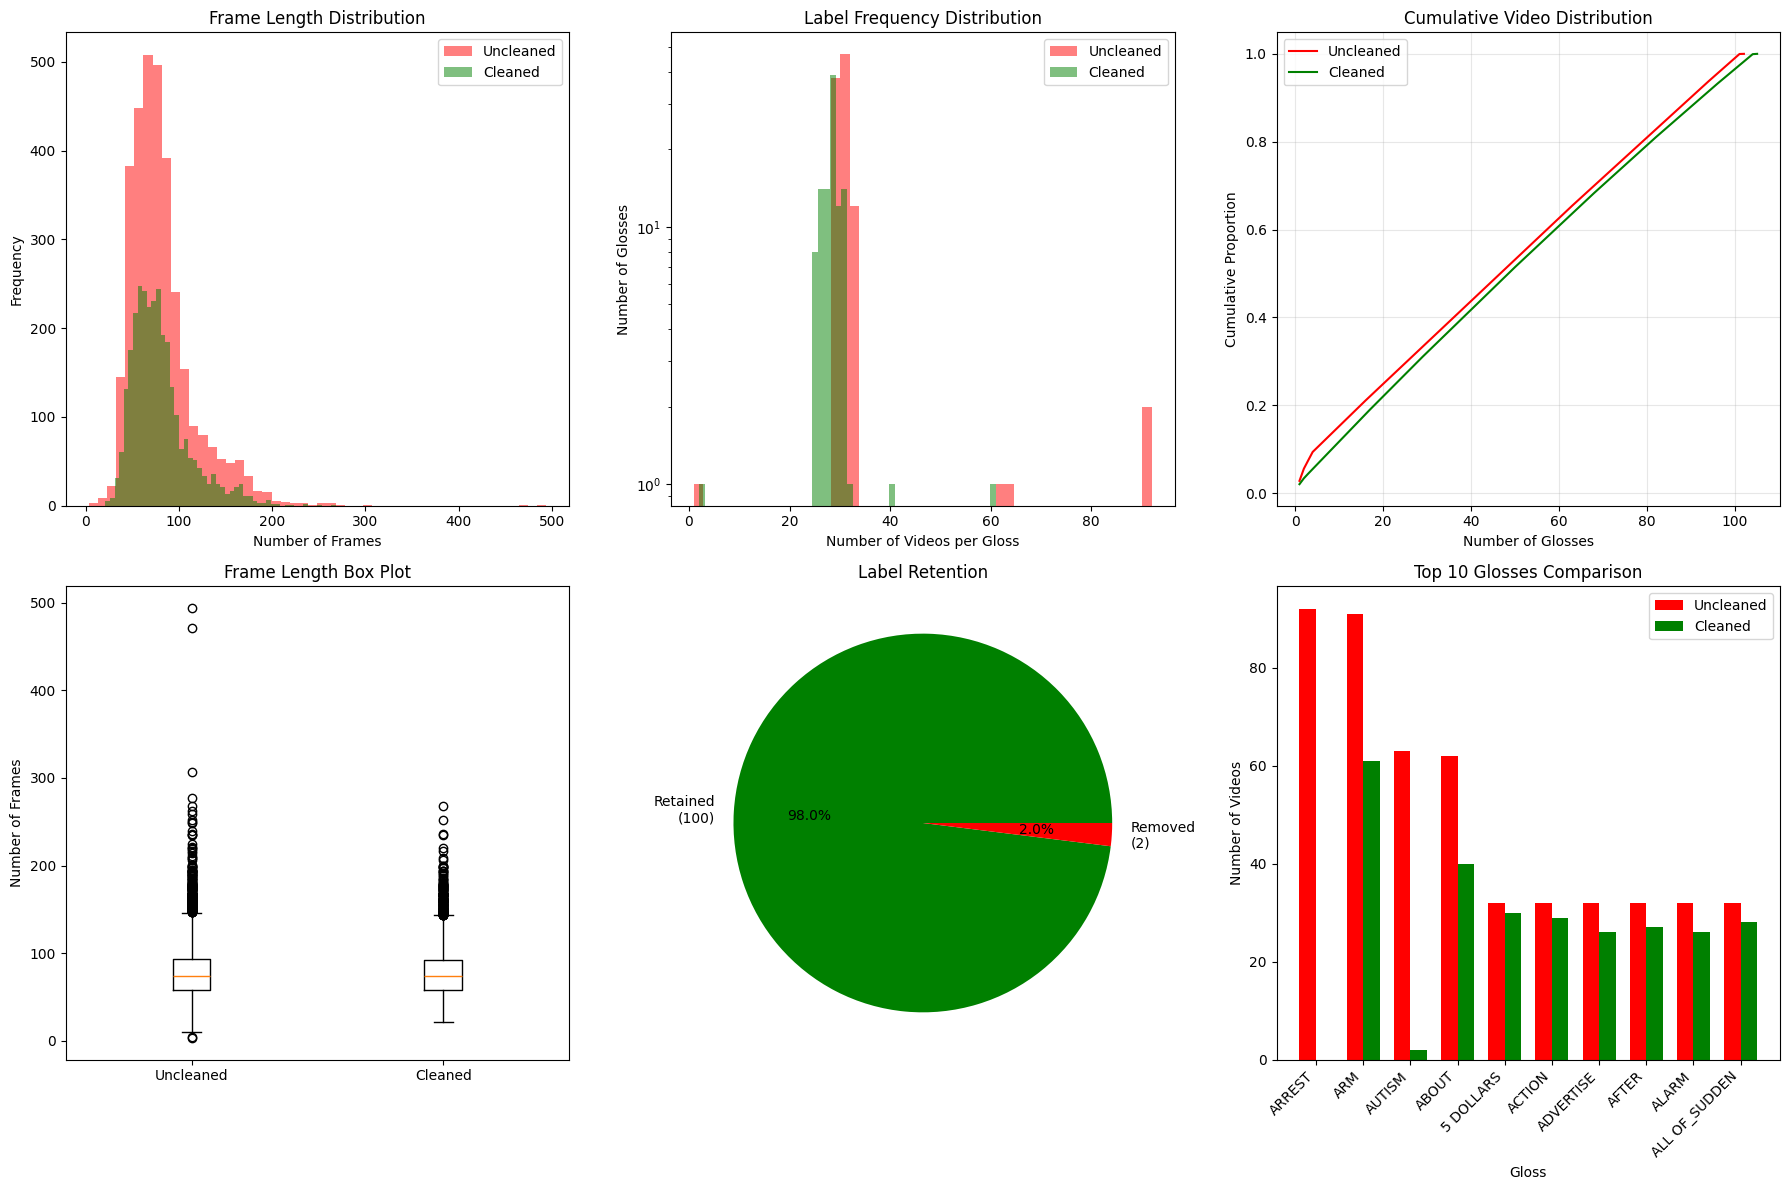

✅ Visualization saved as 'data_comparison.png'

📝 GENERATING COMPARISON REPORT

✅ Report saved to cleaning_comparison_report.txt

✅ COMPARISON COMPLETE!

📊 Key Findings:
  Videos removed: 299
  Glosses removed: -3
  Average frame reduction: 2.0 frames


In [11]:
# Initialize comparator
from CompareData import DataComparator



comparator = DataComparator(
    uncleaned_data=ordinary_data,
    uncleaned_labels=ordinary_labels,
    cleaned_data=cleaned_data,
    cleaned_labels=cleaned_labels
)

# Run full comparison
results = comparator.run_full_comparison()

# Access specific results
print(f"\n📊 Key Findings:")
print(f"  Videos removed: {len(ordinary_data) - len(cleaned_data)}")
print(f"  Glosses removed: {len(np.unique(ordinary_labels)) - len(np.unique(cleaned_labels))}")
print(f"  Average frame reduction: {np.mean([len(seq) for seq in ordinary_data]) - np.mean([len(seq) for seq in cleaned_data]):.1f} frames")